#Atividade prática MatplotLib

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

In [3]:
df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

#Parte 01
##Gráficos Essenciais e Personalização (Básico)

1. Construa um gráfico de linha (plt.plot ou ax.plot) mostrando o faturamento mensal total (resample('ME')). Adicione marcadores circulares ('o'), linha tracejada ('--'), cor customizada, grade (grid) e rótulos para os eixos X e Y.

In [4]:
faturamento_mensal = df.resample('ME', on='data')['valor_venda'].sum()


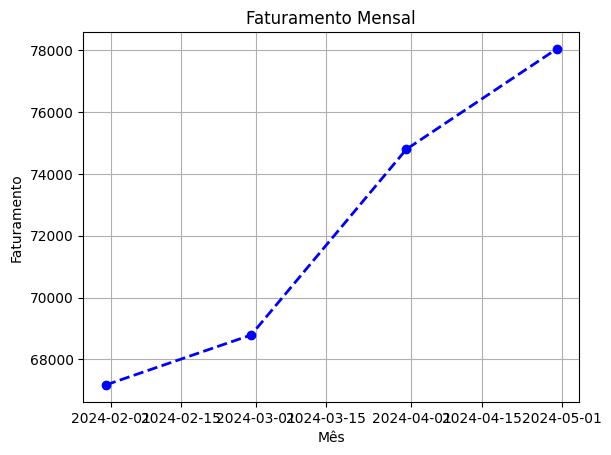

In [5]:
plt.plot(faturamento_mensal.index, faturamento_mensal.values, marker='o', linestyle='--', color='blue', linewidth=2)
plt.grid(True)
plt.xlabel('Mês')
plt.ylabel('Faturamento')
plt.title('Faturamento Mensal')
plt.show()

2. Crie um gráfico de barras (plt.bar) com o total de vendas por categoria ordenado do menor para o maior valor, rotacionando os rótulos do eixo X em 45 graus.

In [6]:
vendas_categoria = df['categoria'].value_counts().sort_values()

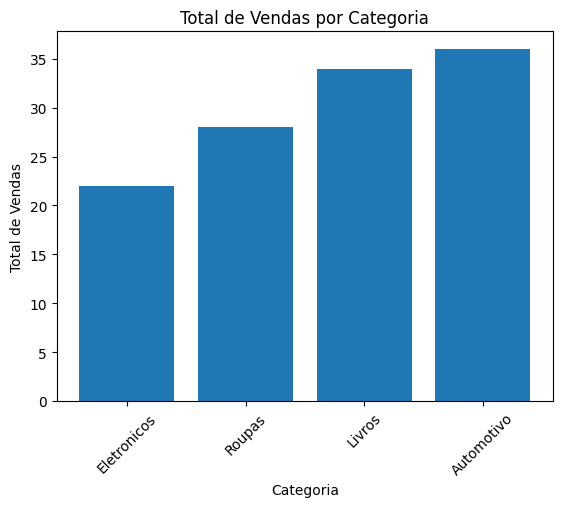

In [7]:
plt.bar(vendas_categoria.index, vendas_categoria.values)
plt.xticks(rotation=45)
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas')
plt.title('Total de Vendas por Categoria')
plt.show()

3. Crie um histograma (plt.hist) da coluna valor com 10 bins e bordas destacadas (edgecolor='black') para analisar a distribuição dos valores das vendas.

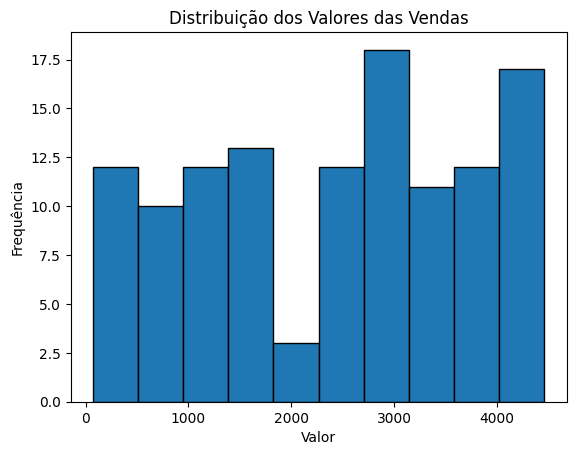

In [8]:
plt.hist(df['valor'], bins=10, edgecolor='black')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.title('Distribuição dos Valores das Vendas')
plt.show()

#Parte 02
##API Orientada a Objetos e Eixos Múltiplos (Intermediário)

4. Crie uma figura com uma grade 2 x 1 de subplots (fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)) com o eixo X compartilhado:
- ax1 (Superior): Gráfico de linha com o faturamento mensal.
- ax2 (Inferior): Gráfico de barras com a quantidade total de itens vendidos no mesmo período.

In [9]:
faturamento_mensal = df.groupby(df['data'].dt.to_period('M'))['valor_venda'].sum()
quantidade_vendida = df.groupby(df['data'].dt.to_period('M'))['quantidade'].sum()


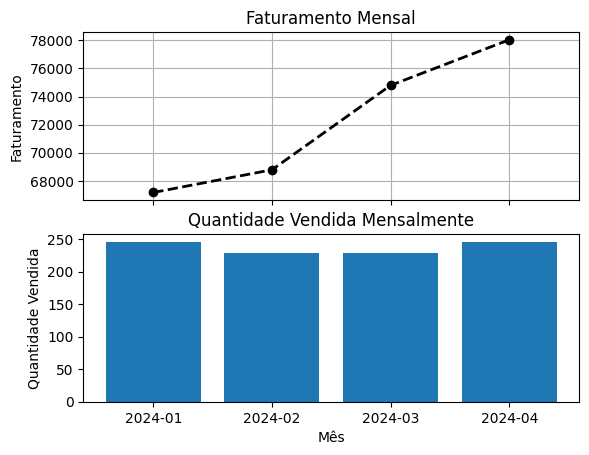

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(faturamento_mensal.index.astype(str), faturamento_mensal.values, marker='o', linestyle='--', color='black', linewidth=2)
ax1.grid(True)
ax1.set_ylabel('Faturamento')
ax1.set_title('Faturamento Mensal')
ax2.bar(quantidade_vendida.index.astype(str), quantidade_vendida.values)
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade Vendida')
ax2.set_title('Quantidade Vendida Mensalmente')
plt.show()

5. Crie um gráfico com dois eixos Y (ax.twinx()):
- No eixo primário (à esquerda), exiba o valor total vendido por mês em barras.
- No eixo secundário (à direita), plote a quantidade média de itens por venda em linha com marcadores.

In [11]:
quantidade_media = df.groupby(df['data'].dt.to_period('M'))['quantidade'].mean()

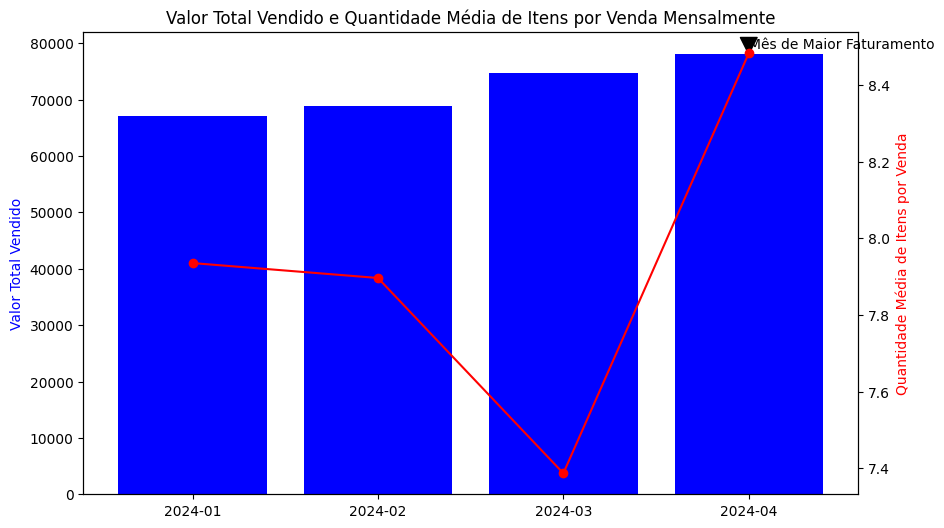

In [12]:
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.bar(faturamento_mensal.index.astype(str), faturamento_mensal.values, color='blue')
ax2.plot(quantidade_media.index.astype(str), quantidade_media.values, marker='o', color='red')
ax1.set_ylabel('Valor Total Vendido', color='blue')
ax2.set_ylabel('Quantidade Média de Itens por Venda', color='red')
plt.title('Valor Total Vendido e Quantidade Média de Itens por Venda Mensalmente')
ax1.annotate('Mês de Maior Faturamento', xy=(str(faturamento_mensal.idxmax()), faturamento_mensal.max()), xytext=(str(faturamento_mensal.idxmax()), faturamento_mensal.max() + 1000),
             arrowprops=dict(facecolor='black', shrink=0.05)
             )
plt.show()

6. No gráfico de linha mensal, identifique o mês de maior faturamento e adicione uma anotação com seta apontando para o pico usando ax.annotate().<br>
Como pode ser visto acima

#Parte 03
##Matriz de Intensidade / Heatmap (Intermediário / Avançado)

7. Construa uma tabela dinâmica (pd.pivot_table) somando os valores de venda agrupados por categoria nas linhas e estado nas colunas.

In [13]:
tabela = pd.pivot_table(df, values='valor_venda', index='categoria', columns='estado', aggfunc='sum')

8. Renderize essa matriz na forma de um Heatmap utilizando plt.imshow(), incluindo uma barra de cores (plt.colorbar()) e os respectivos rótulos nominais nas marcações dos eixos X (xticks) e Y (yticks).

([<matplotlib.axis.YTick at 0x7fc00696ccd0>,
 [Text(0, 0, 'Automotivo'),
  Text(0, 1, 'Eletronicos'),
  Text(0, 2, 'Livros'),
  Text(0, 3, 'Roupas')])

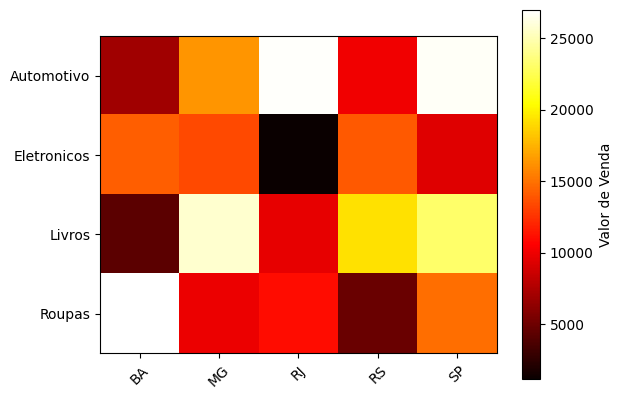

In [14]:
plt.imshow(tabela, cmap='hot', interpolation='nearest')
plt.colorbar(label='Valor de Venda')
plt.xticks(np.arange(len(tabela.columns)), tabela.columns, rotation=45)
plt.yticks(np.arange(len(tabela.index)), tabela.index)

9. Salve a figura gerada no passo 8 em um arquivo de imagem 'heatmap_vendas.png' com resolução de 300 DPI e corte ajustado (bbox_inches='tight').

In [15]:
plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>